In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Phase 1  
-----------------------------------------
Load, Explore & Clean
-----------------------------------------

In [9]:
df=pd.read_csv("AmesHousing.csv")
print(df.head())
# [5 rows x 82 columns]

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [10]:
df.info()
# i used ai
# i used to_numeric For digital transformation,I used fillna to compensate for the missing values; if there are no NaN values, I can use regular int64, but if there are still missing values, I must use int64 (with a large I) because it does not support null values
df['Mas Vnr Area'] = pd.to_numeric(df['Mas Vnr Area'], errors='coerce').fillna(0).astype('int64')
df['BsmtFin SF 1'] = pd.to_numeric(df['BsmtFin SF 1'], errors='coerce').fillna(0).astype('int64')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [11]:
# i used ai to get the top colunm that have Nan value
missing_d=df.isnull().sum()
print(missing_d[missing_d>0])
# Pool QC have the most

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [13]:
# ---------------------------------------------------------
# i used drop here if there any colunm have 500 Nan or more than 500 Nan i drop it because they have a lot of missing value
# i used ai to fix drop of column
for a in df.columns:
  try:
    if df[a].isnull().sum()>=500 :
      drop_c=df[a]
      df.drop(columns=a,inplace=True)
  except:
    df.drop(columns=a)
# ----------------------------------------------------
# i used fillna here to the values between 1 and 499
# i used ai to fix Spelling error and use mode
for i in df.columns:
  try:
    if df[i].isnull().sum()>0 and df[i].isnull().sum()<500:
      df[i].fillna(df[i].median(),inplace=True)
  except:
    df[i]=df[i].fillna(df[i].mode()[0], inplace=True)

missing_d=df.isnull().sum()
print(missing_d[missing_d>0])

# Just press the button twice because it displays a warning message.


Series([], dtype: int64)


In [14]:
print(df)

      Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL          68.0      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9627   Pave   

     Lot Shape Land Contour Utilities  

99th percentile cap value: 10.0


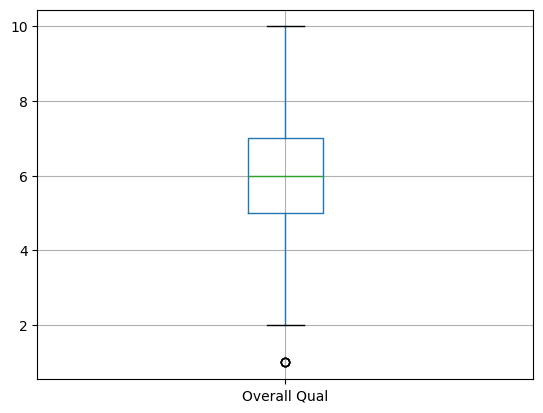

In [15]:
df.boxplot(column="Overall Qual")
# i used ai
cap_value=df['Overall Qual'].quantile(0.99)
print(f"99th percentile cap value: {cap_value}")

99th percentile cap value: 10.0


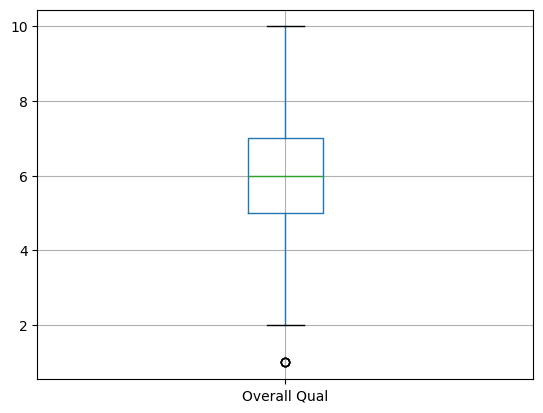

In [16]:
def clean_data():
  df=pd.read_csv("AmesHousing.csv")
  # ---------------------------------
  df.info()
  df['Mas Vnr Area'] = pd.to_numeric(df['Mas Vnr Area'], errors='coerce').fillna(0).astype('int64')
  df['BsmtFin SF 1'] = pd.to_numeric(df['BsmtFin SF 1'], errors='coerce').fillna(0).astype('int64')
  # ---------------------------------
  df.isnull().sum()

  for a in df.columns:
    try:
      if df[a].isnull().sum()>=500 :
        drop_c=df[a]
        df.drop(columns=a,inplace=True)
    except:
      df.drop(columns=a)

  for i in df.columns:
    try:
      if df[i].isnull().sum()>0 and df[i].isnull().sum()<500:
        df[i].fillna(df[i].median(),inplace=True)
    except:
      df[i]=df[i].fillna(df[i].mode()[0], inplace=True)

  missing_d=df.isnull().sum()
  print(missing_d[missing_d>0])

  # ---------------------------------
df.boxplot(column="Overall Qual")
cap_value=df['Overall Qual'].quantile(0.99)
print(f"99th percentile cap value: {cap_value}")




In [17]:
# i used ai
assert df["Overall Qual"].notnull().all()
# --------------------------------
assert (df["Overall Cond"]>0).all()
# --------------------------------
colunm_expected=len(df.columns)
assert len(df.columns)==colunm_expected

Phase 2
-----------------------------------------
Engineer & Transform Features
--------------------------------

In [18]:
df_ohe=pd.get_dummies(df,columns=["Street"],prefix=["Alley"])
print(df_ohe.head())
# the code create new colunm like Alley_Grvl,Alley_Pave

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Lot Shape  \
0      1  526301100           20        RL         141.0     31770       IR1   
1      2  526350040           20        RH          80.0     11622       Reg   
2      3  526351010           20        RL          81.0     14267       IR1   
3      4  526353030           20        RL          93.0     11160       Reg   
4      5  527105010           60        RL          74.0     13830       IR1   

  Land Contour Utilities Lot Config  ... Screen Porch Pool Area Misc Val  \
0          Lvl    AllPub     Corner  ...            0         0        0   
1          Lvl    AllPub     Inside  ...          120         0        0   
2          Lvl    AllPub     Corner  ...            0         0    12500   
3          Lvl    AllPub     Corner  ...            0         0        0   
4          Lvl    AllPub     Inside  ...            0         0        0   

  Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  Alley_

In [20]:
Ms_subClass=pd.CategoricalIndex(df["MS SubClass"],ordered=True)
print(Ms_subClass.categories)

Index([20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 150, 160, 180, 190], dtype='int64')


In [21]:
from sklearn.preprocessing import StandardScaler
# here I used StandardScaler()
std_scaler=StandardScaler()
# here I copied the (df)
df_std=df.copy()
df_std[["Lot Frontage_std","Lot Area_std"]]=std_scaler.fit_transform(df_std[["Lot Frontage","Lot Area"]])
print(df_std[["Lot Frontage","Lot Area","Lot Frontage_std","Lot Area_std"]])


      Lot Frontage  Lot Area  Lot Frontage_std  Lot Area_std
0            141.0     31770          3.375742      2.744381
1             80.0     11622          0.514952      0.187097
2             81.0     14267          0.561850      0.522814
3             93.0     11160          1.124628      0.128458
4             74.0     13830          0.233563      0.467348
...            ...       ...               ...           ...
2925          37.0      7937         -1.501671     -0.280621
2926          68.0      8885         -0.047827     -0.160296
2927          62.0     10441         -0.329216      0.037199
2928          77.0     10010          0.374257     -0.017506
2929          74.0      9627          0.233563     -0.066118

[2930 rows x 4 columns]


In [22]:
# i used ai and i learnd how to use (where)
df["price_per_sqft"]=np.where(df["Gr Liv Area"]>0,df["Gr Liv Area"]/df["SalePrice"],0)

df["room_per_sqft"]=np.where(df["Gr Liv Area"]>0,df["TotRms AbvGrd"]/df["Gr Liv Area"],0)

print(df["price_per_sqft"])
print(df["room_per_sqft"])


0       0.007702
1       0.008533
2       0.007727
3       0.008648
4       0.008578
          ...   
2925    0.007039
2926    0.006885
2927    0.007348
2928    0.008171
2929    0.010638
Name: price_per_sqft, Length: 2930, dtype: float64
0       0.004227
1       0.005580
2       0.004515
3       0.003791
4       0.003683
          ...   
2925    0.005982
2926    0.005543
2927    0.006186
2928    0.004320
2929    0.004500
Name: room_per_sqft, Length: 2930, dtype: float64


In [23]:
df["Overall ratting"]=df["Lot Area"]*df["Overall Qual"]
print(df["Overall ratting"])

0       190620
1        58110
2        85602
3        78120
4        69150
         ...  
2925     47622
2926     44425
2927     52205
2928     50050
2929     67389
Name: Overall ratting, Length: 2930, dtype: int64


0       4.955827
1       4.394449
2       4.406719
3       4.543295
4       4.317488
          ...   
2925    3.637586
2926    4.234107
2927    4.143135
2928    4.356709
2929    4.317488
Name: Lot Frontage_log, Length: 2930, dtype: float64


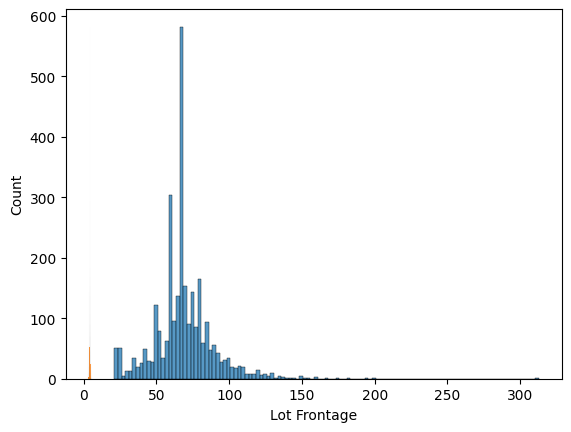

In [24]:
df["Lot Frontage_log"]= np.log1p(df["Lot Frontage"])
# it is print the old one
sns.histplot(df["Lot Frontage"])
# it is print the new one after log1p
sns.histplot(df["Lot Frontage_log"])
print(df["Lot Frontage_log"])

In [25]:
# i used ai to debug how can i but the final values into the (df["rate"]) and i but (=) from ai
rates=[]
# Here I used the (for) function to input all the data and divide it
for i in df["Year Built"]:
      if i >= 1988 and i <= 1999:
        rates.append("NEW")
      elif i >= 2001:
        rates.append("RECENT")
      else:
        rates.append("OLD")
# Here I used it to record it in the data frame
df["rate"]=rates

In [26]:
print(df["rate"])

0       OLD
1       OLD
2       OLD
3       OLD
4       NEW
       ... 
2925    OLD
2926    OLD
2927    NEW
2928    OLD
2929    NEW
Name: rate, Length: 2930, dtype: object


In [27]:
# i used ai
corr_matrix=df.select_dtypes(include="number").corr().abs()
todrop=set()
for i in range(len(corr_matrix.columns)):
  for j in range(i):
    if corr_matrix.iloc[i,j]>0.95:
      clname=corr_matrix.columns[i]
      todrop.add(clname)
df_sim=df.drop(columns=todrop)
print(f"what need to drop ={todrop}")


what need to drop ={'Yr Sold'}


Phase 3
----
 Analyse, Visualise & Report
 -----

Text(0.5, 1.0, 'Histogram of Mas Vnr Area')

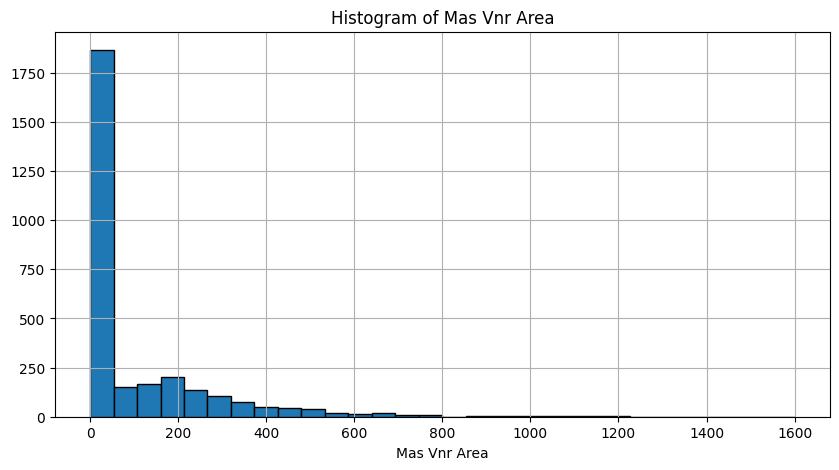

In [28]:
df["Mas Vnr Area"].hist(bins=30,figsize=(10,5),edgecolor="black")
plt.xlabel("Mas Vnr Area")
plt.title("Histogram of Mas Vnr Area")
# it is skewed to right




Text(0.5, 1.0, 'Histogram of Overall Qual')

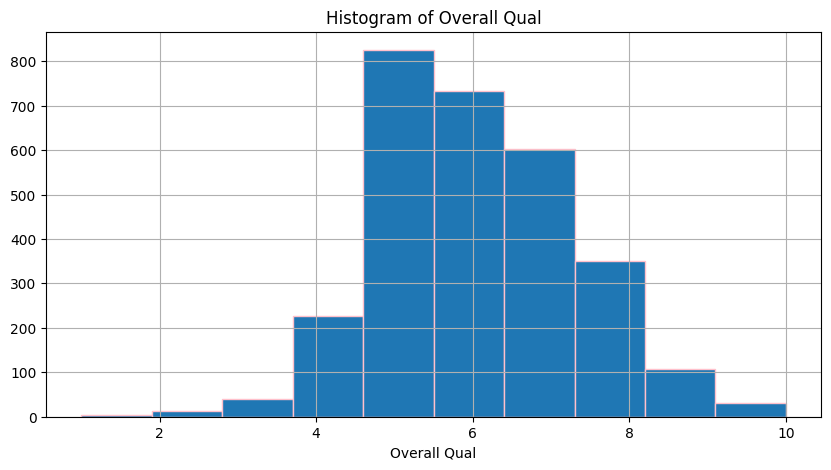

In [29]:
df["Overall Qual"].hist(bins=10,figsize=(10,5),edgecolor="pink",)
plt.xlabel("Overall Qual")
plt.title("Histogram of Overall Qual")
# it is skewed to right

Text(0.5, 1.0, 'KDE Plot of Lot Frontage')

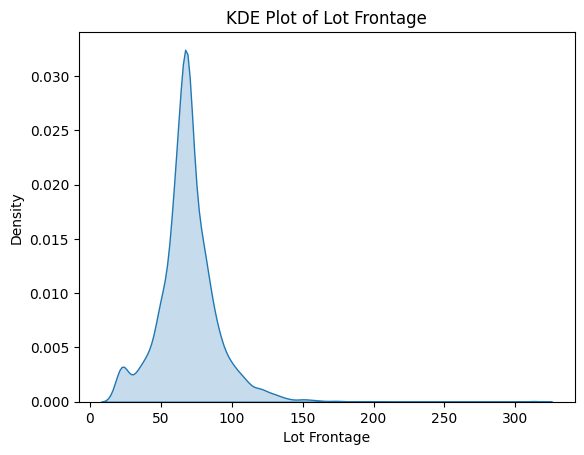

In [30]:
sns.kdeplot(df["Lot Frontage"],fill=True)
plt.title("KDE Plot of Lot Frontage")
# it is skewed to right

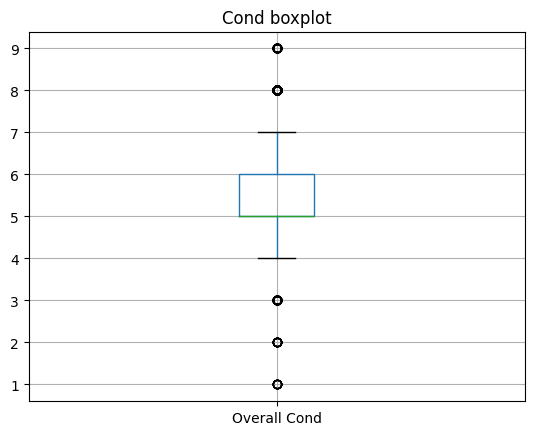

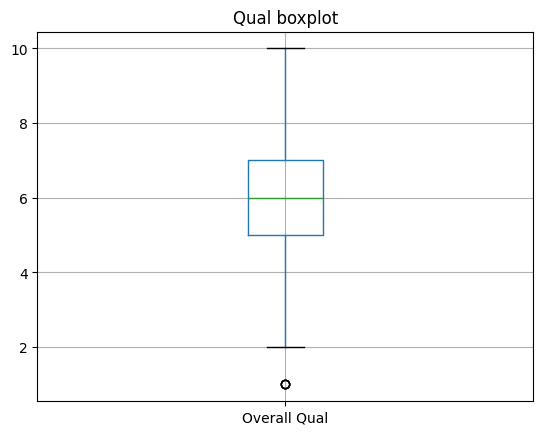

Text(0.5, 1.0, 'overall boxplot')

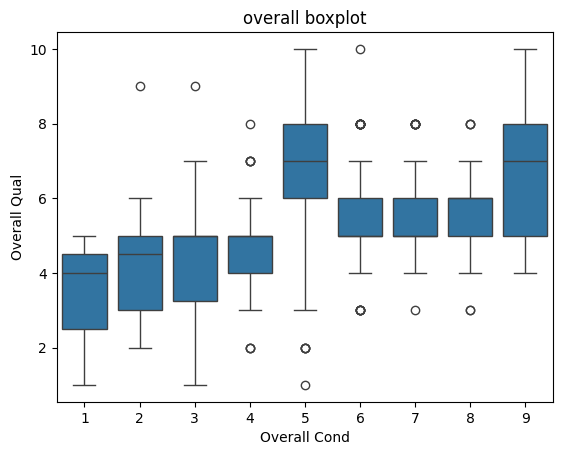

In [31]:
# this is Overall Cond boxplot
df.boxplot(column="Overall Cond")
plt.title("Cond boxplot")
plt.show()

# this is Overall Qual boxplot
df.boxplot(column="Overall Qual")
plt.title("Qual boxplot")
plt.show()

# here all of them (Qual,Cond)
sns.boxplot(x=df["Overall Cond"], y=df["Overall Qual"], data=df)
plt.title("overall boxplot")



<Axes: >

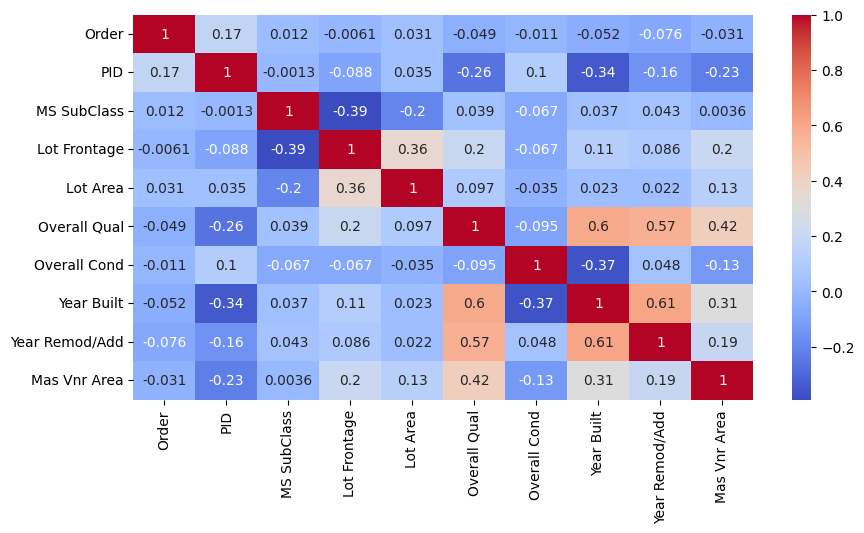

In [32]:
# i used ai
# here he chose the colunms that have numbers
corr_matrix = df.select_dtypes(include=['number']).corr()
# here the top 10 futures
top_10= corr_matrix['SalePrice'].head(10).index
top_corr = corr_matrix.loc[top_10, top_10]

plt.figure(figsize=(10,5))
sns.heatmap(top_corr, annot=True, cmap='coolwarm', )


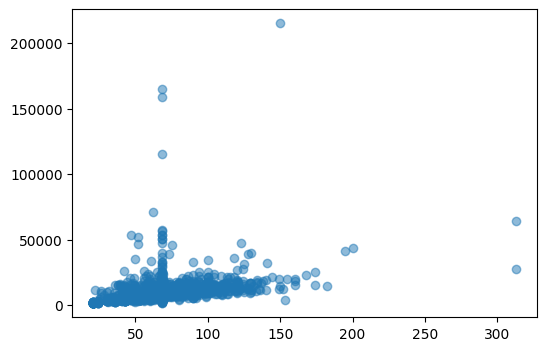

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(x=df["Lot Frontage"],y=df["Lot Area"], alpha=0.5)


In [34]:
gropby_df=df.groupby("Year Built")["Yr Sold"].agg(["count","mean"])
print(gropby_df)

            count         mean
Year Built                    
1872            1  2008.000000
1875            1  2010.000000
1879            1  2007.000000
1880            5  2007.800000
1882            1  2009.000000
...           ...          ...
2006          138  2007.065217
2007          109  2007.825688
2008           49  2008.795918
2009           25  2009.520000
2010            3  2010.000000

[118 rows x 2 columns]


In paragraph 1, It explained the
Mas Vnr Area column, showing where the data is collected and where it veers off,using histplot.


In paragraph 2, It explained the Overall Qual column, showing where the data is collected and where it veers off, using histplot.


In paragraph 3, It explained theLot Frontage column, showing where the data is collected and where it veers off,using kdeplot.


In paragraph 4, there are 3 shapes: the first one shows column Overall Cond, the second one shows column Overall Qual, and the third one shows Overall Cond and Overall Qual together.it show where the main values and the outliers values .


In Paragraph 5, explains the extent to which data containing numbers are related to a single objective.

In paragraph 6, it explains where the data is collected and what the outlier values ​​are in column Lot Frontage.

In [35]:
# Here data was recorded from the dataframe to the array
mo=df["Mo Sold"]
s=np.array([mo])
print(s)
# This is where the process of collecting enemies begins
for i in mo:
  i=i+i
#After adding them up, we check the result so we can divide by their number.
if i==0 :
  print("Error")
elif len(mo)==2930:
  i/2930
  print(f"mean={i}")
else:
  print("there are 0 in num")

print(f"std={mo.std()}")

[[ 5  6  6 ...  7  4 11]]
mean=22
std=2.71449242543017


In [36]:
# i used ai to debug the reshape and to but one colunm (Overall cond) in StandardScaler
cond=df["Overall Cond"]
x=np.array([cond]).reshape(-1, 1)

means=x.mean(axis=0,keepdims=True)
stds=x.std(axis=0,keepdims=True)
x_std=(x-means)/ stds
print(x_std)

from sklearn.preprocessing import StandardScaler
# here I used StandardScaler()
std_scaler=StandardScaler()
# here I copied the (df)
df_std=df.copy()
df_std["Overall Cond_std"]=std_scaler.fit_transform(df_std[["Overall Cond"]])
print(df_std[["Overall Cond","Overall Cond_std"]])

# there is no difference between them


[[-0.50671843]
 [ 0.39309066]
 [ 0.39309066]
 ...
 [-0.50671843]
 [-0.50671843]
 [-0.50671843]]
      Overall Cond  Overall Cond_std
0                5         -0.506718
1                6          0.393091
2                6          0.393091
3                5         -0.506718
4                5         -0.506718
...            ...               ...
2925             6          0.393091
2926             5         -0.506718
2927             5         -0.506718
2928             5         -0.506718
2929             5         -0.506718

[2930 rows x 2 columns]


In [37]:
a1=df["Lot Frontage"]
b1=df["Lot Area"]


a2=np.array([a1])
b2=np.array([b1])

def cosine_similarity(a, b):
  return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
u = np.array([1.0, 0.0]); v = np.array([0.0, 1.0])
print("cos(u, v):", cosine_similarity(u, v))
# Two directions are perpendicular because the result is 0

cos(u, v): 0.0


In [39]:
# i used ai and he told me how to get the largest value and lowest value and in cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity

top_v=df["Overall Cond"].idxmax()
low_v=df["Overall Cond"].idxmin()

df_num=df.select_dtypes(include=['number']).fillna(0)


v1=df_n um.loc[[top_v]].values
v2=df_num.loc[[low_v]].values

sim= cosine_similarity(v1, v2)

print(f"cosine similarity={sim[0][0]}")


cosine similarity=0.9999999964079891


In [42]:
# i used ai
quality_threshold = 8
price_threshold = 300000

high_quality_items = df[df['Overall Qual'] >= quality_threshold]
total_high_quality = len(high_quality_items)

above_threshold = high_quality_items[high_quality_items['SalePrice'] > price_threshold]
count_above = len(above_threshold)

probability = count_above / total_high_quality
print(f"={probability:.2%}")

=43.24%
